### Import / Familiarize with data

In [33]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pandas as pd

data = load_digits()
X = data.data
y = data.target

print(X.shape, y.shape)
np.bincount(y)

(1797, 64) (1797,)


array([178, 182, 177, 183, 181, 182, 181, 179, 174, 180])

### Numerical pipeline + StandardScaler + PCA

 - Datasets from sklearn are always complete and purely numerical, so there is no need to fill in missing data

In [34]:
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
])

X_pca = pca_pipeline.fit_transform(X)
pca_model = pca_pipeline.named_steps['pca']
print(X_pca.shape)
print(pca_model.explained_variance_ratio_)

(1797, 64)
[1.20339161e-01 9.56105440e-02 8.44441489e-02 6.49840791e-02
 4.86015488e-02 4.21411987e-02 3.94208280e-02 3.38938092e-02
 2.99822101e-02 2.93200255e-02 2.78180546e-02 2.57705509e-02
 2.27530332e-02 2.22717974e-02 2.16522943e-02 1.91416661e-02
 1.77554709e-02 1.63806927e-02 1.59646017e-02 1.48919119e-02
 1.34796957e-02 1.27193137e-02 1.16583735e-02 1.05764660e-02
 9.75315947e-03 9.44558990e-03 8.63013827e-03 8.36642854e-03
 7.97693248e-03 7.46471371e-03 7.25582151e-03 6.91911245e-03
 6.53908536e-03 6.40792574e-03 5.91384112e-03 5.71162405e-03
 5.23636803e-03 4.81807586e-03 4.53719260e-03 4.23162753e-03
 4.06053070e-03 3.97084808e-03 3.56493303e-03 3.40787181e-03
 3.27835335e-03 3.11032007e-03 2.88575294e-03 2.76489264e-03
 2.59174941e-03 2.34483006e-03 2.18256858e-03 2.03597635e-03
 1.95512426e-03 1.83318499e-03 1.67946387e-03 1.61236062e-03
 1.47762694e-03 1.35118411e-03 1.25100742e-03 1.03695730e-03
 8.25350945e-04 9.10778070e-19 0.00000000e+00 0.00000000e+00]


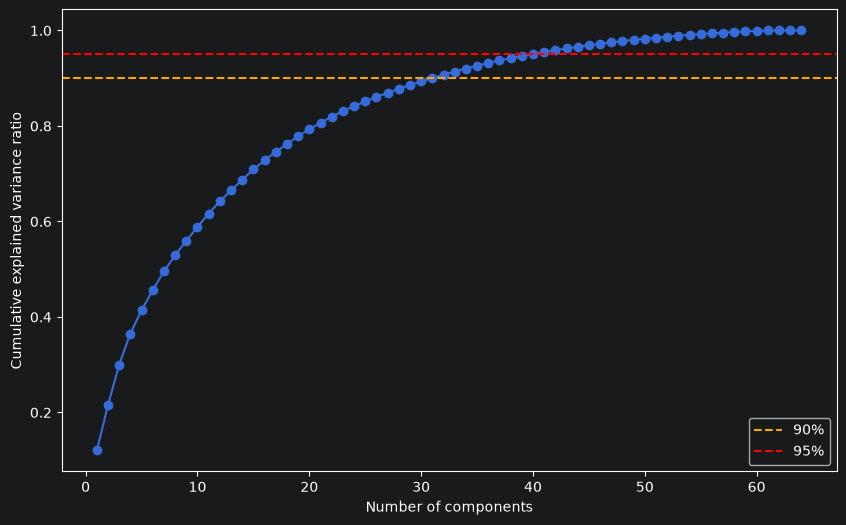

90%: 31 komponentów, 95%: 40 komponentów


In [35]:
cumulative = np.cumsum(pca_pipeline.named_steps['pca'].explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o')
plt.axhline(0.90, linestyle='--', color='orange', label='90%')
plt.axhline(0.95, linestyle='--', color='red', label='95%')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance ratio")
plt.legend()
plt.show()

n_90 = np.argmax(cumulative >= 0.90) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1
print(f"90%: {n_90} komponentów, 95%: {n_95} komponentów")

### PCA on digits — how many components are enough?

 - With just 5 components, only ~41% of variance is retained. Reaching 90% requires
   30 components, and 95% requires 40 components — out of 64 total.
 - Unlike `wine`, where 2 components already captured ~55% of variance, `digits` needs
   roughly half of its original 64 features to reach a similar 90%+ threshold. This
   suggests the information in pixel data is spread across many directions rather than
   concentrated in a few dominant ones, likely because handwritten digit shapes vary
   in many independent ways (stroke width, slant, size) that don't correlate strongly
   with each other.
 - Consequence: for visualization, 2 components are still useful despite the low
   retained variance (12-21%), since the goal is only a rough overview. For any
   downstream modeling task, a much higher number of components (30-40) would be
   needed to avoid meaningfully degrading performance.

### K-Means, silhouette score and inertia

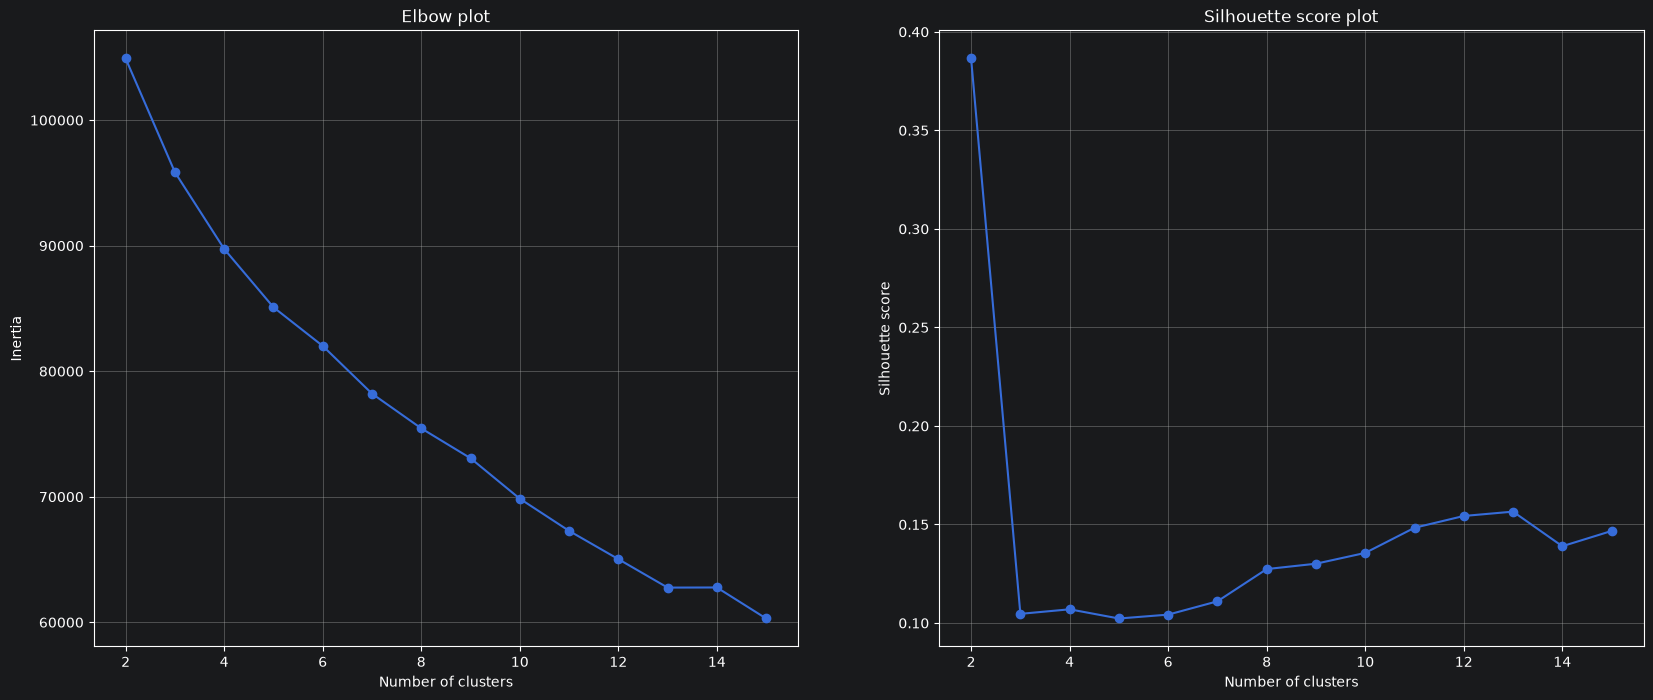

In [36]:
inertias = []
silhouettes = []

for k in range(2, 16):
    km_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=k, random_state=42)),
    ])

    km_pipeline.fit(X)
    inertia = km_pipeline['kmeans'].inertia_
    inertias.append(inertia)

    X_scaled = km_pipeline[:-1].transform(X)
    labels = km_pipeline['kmeans'].labels_
    silhouette = silhouette_score(X_scaled, labels)
    silhouettes.append(silhouette)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.plot(range(2, 16), inertias, marker='o', linestyle='-')
ax1.set_title("Elbow plot")
ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("Inertia")
ax1.grid(True)

ax2.plot(range(2, 16), silhouettes, marker='o', linestyle='-')
ax2.set_title("Silhouette score plot")
ax2.set_xlabel("Number of clusters")
ax2.set_ylabel("Silhouette score")
ax2.grid(True)

In [37]:
km_10 = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=10, random_state=42))
])
km_10.fit(X)
labels_10 = km_10['kmeans'].labels_

pd.crosstab(y, labels_10)

col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,0,0,2,0,0,176,0,0,0,0
1,0,0,49,0,0,0,27,0,1,105
2,0,0,3,1,0,1,141,5,0,26
3,0,8,0,7,0,0,1,160,0,7
4,9,0,155,14,0,0,0,0,1,2
5,0,120,3,1,3,0,0,52,0,3
6,0,0,0,0,175,1,0,0,0,5
7,17,2,2,157,0,0,0,0,0,1
8,0,6,3,4,2,0,1,50,0,108


### K-Means on digits (k=10) — does it recover the real digit classes?

 - Silhouette score peaks at k=2 (0.385) and stays low (0.10-0.15) across the rest
   of the range, including k=10 — despite there being exactly 10 true digit classes.
   A crosstab of true labels vs. cluster assignments at k=10 shows why: digits 0 and 6
   separate almost perfectly into their own clusters (176/178 and 175/178 respectively),
   but several clusters mix multiple digits together — e.g. one cluster contains both
   digit 4 (155) and digit 1 (49), another mixes digits 3 (160), 5 (52), and 8 (50)
   into a single cluster.
 - K-Means groups points purely by Euclidean distance between raw pixel values, with
   no concept of what a digit "means." Visually similar shapes (3/5/8, or 1/4) produce
   overlapping pixel patterns, so the algorithm merges them into shared clusters, while
   visually distinctive shapes (0, 6) separate cleanly. This contrasts with `wine`,
   where all 3 true classes separated cleanly at k=3 — chemical composition features
   apparently create more naturally distinct clusters than raw pixel data does.
 - Consequence: matching the true number of classes (k=10) does not guarantee that
   K-Means recovers meaningful, human-aligned categories. Cluster quality (via
   silhouette) and label alignment (via crosstab) need to be checked separately —
   a good silhouette score doesn't guarantee clusters match real-world categories,
   and knowing the "correct" k doesn't guarantee K-Means will find it unsupervised.